## 04 - Random Forest

**Tech Challenge — Fase 1 | Machine Learning Engineering — FIAP**

**Projeto:** Customer Churn Prediction

**Grupo:** 56

---

### ETAPA 1 - Introdução e Objetivos

Após a construção da Regressão Logística como modelo baseline, esta etapa do projeto tem como objetivo desenvolver e avaliar um modelo baseado em ensemble de árvores utilizando o algoritmo Random Forest.

O Random Forest combina múltiplas árvores de decisão para produzir previsões mais robustas, reduzindo a dependência de uma única árvore e permitindo capturar relações não lineares e interações mais complexas entre as variáveis.

Para garantir uma comparação consistente com o modelo baseline, serão mantidos o mesmo conjunto de dados, a mesma divisão entre treino e teste e o mesmo protocolo de avaliação utilizado anteriormente.

O desempenho será analisado por meio das métricas PR-AUC (Average Precision), ROC-AUC, Recall, Precision, F1-Score e Accuracy, além da matriz de confusão e das curvas ROC e Precision-Recall.

Também será aplicada validação cruzada para avaliar a estabilidade do modelo e será analisada a importância das variáveis utilizadas nas previsões.

### Objetivos

- Construir um pipeline de pré-processamento e classificação com Random Forest;
- Treinar o modelo utilizando o conjunto de treinamento;
- Gerar classes e probabilidades previstas;
- Avaliar o desempenho utilizando as métricas definidas no projeto;
- Analisar os erros por meio da matriz de confusão;
- Avaliar as curvas ROC e Precision-Recall;
- Aplicar validação cruzada para analisar a estabilidade do modelo;
- Analisar a importância das variáveis;
- Registrar os resultados para posterior comparação com a Regressão Logística e o MLPClassifier.

---

In [1]:
# ============================================================
# ETAPA 2 - IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

# Configurações gerais
RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_colwidth",
    None
)

print("Bibliotecas importadas com sucesso.")
print(f"Random State definido: {RANDOM_STATE}")

Bibliotecas importadas com sucesso.
Random State definido: 42


In [2]:
# ============================================================
# ETAPA 3 - CARREGAMENTO DA BASE DE DADOS
# ============================================================

DATASET_NAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

current_path = Path.cwd().resolve()

project_root = None

for path in [current_path, *current_path.parents]:

    candidate = (
        path
        / "data"
        / "raw"
        / DATASET_NAME
    )

    if candidate.exists():
        project_root = path
        break


if project_root is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto contendo "
        f"data/raw/{DATASET_NAME}"
    )


DATA_PATH = (
    project_root
    / "data"
    / "raw"
    / DATASET_NAME
)

df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.")
print(
    f"Quantidade de registros: "
    f"{df.shape[0]:,}".replace(",", ".")
)
print(
    f"Quantidade de variáveis: "
    f"{df.shape[1]}"
)
print(
    f"Arquivo utilizado: "
    f"{DATA_PATH.name}"
)

display(df.head())

Base carregada com sucesso.
Quantidade de registros: 7.043
Quantidade de variáveis: 21
Arquivo utilizado: WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Conclusão da ETAPA 3

A base Telco Customer Churn foi carregada com sucesso a partir da estrutura local do projeto.

Foram identificados 7.043 registros e 21 variáveis, mantendo a mesma fonte de dados utilizada nos experimentos anteriores. Essa consistência é fundamental para permitir uma comparação adequada entre a Regressão Logística e o Random Forest.

---

### ETAPA 4 - Preparação das Variáveis

Nesta etapa são realizadas as transformações necessárias para preparar as variáveis utilizadas no treinamento do Random Forest.

A variável `TotalCharges` é convertida para formato numérico e a variável alvo `Churn` é padronizada para representação binária, em que `0` representa clientes que permaneceram e `1` representa clientes que realizaram churn.

Em seguida, o identificador `customerID` é removido das variáveis explicativas, pois não possui significado preditivo direto para o problema.

A preparação mantém o mesmo protocolo utilizado no modelo baseline, garantindo consistência na comparação entre os algoritmos.

In [3]:
# ============================================================
# ETAPA 4 - PREPARAÇÃO DAS VARIÁVEIS
# ============================================================
# Preparação das variáveis utilizadas no treinamento do
# modelo Random Forest.
# ============================================================

df = df.copy()

# ------------------------------------------------------------
# Conversão da variável TotalCharges para formato numérico
# ------------------------------------------------------------

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# ------------------------------------------------------------
# Preparação da variável alvo
# ------------------------------------------------------------

# A conversão é realizada apenas quando Churn ainda estiver
# representado pelas categorias "Yes" e "No".
if not pd.api.types.is_numeric_dtype(df["Churn"]):

    df["Churn"] = (
        df["Churn"]
        .astype(str)
        .str.strip()
        .map({
            "No": 0,
            "Yes": 1
        })
    )


# Validação da variável alvo
if df["Churn"].isna().any():

    valores_invalidos = df.loc[
        df["Churn"].isna(),
        "Churn"
    ]

    raise ValueError(
        "Foram encontrados valores inválidos ou ausentes "
        "na variável alvo Churn."
    )


df["Churn"] = df["Churn"].astype(int)


# ------------------------------------------------------------
# Separação das variáveis explicativas e variável alvo
# ------------------------------------------------------------

X = df.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

y = df["Churn"]


# ------------------------------------------------------------
# Validações
# ------------------------------------------------------------

if not set(y.unique()).issubset({0, 1}):
    raise ValueError(
        "A variável Churn deve conter somente os valores 0 e 1."
    )


# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Variáveis preparadas com sucesso.")

print(
    f"Variáveis explicativas: "
    f"{X.shape[1]}"
)

print(
    f"Observações: "
    f"{X.shape[0]:,}".replace(",", ".")
)

print(
    f"Classe positiva (Churn): "
    f"{y.sum():,}".replace(",", ".")
)

print(
    f"Taxa de Churn: "
    f"{y.mean():.2%}"
)

Variáveis preparadas com sucesso.
Variáveis explicativas: 19
Observações: 7.043
Classe positiva (Churn): 1.869
Taxa de Churn: 26.54%


#### Conclusão da ETAPA 4

As variáveis foram preparadas com sucesso para a etapa de modelagem. Após a remoção do identificador `customerID`, o conjunto passou a conter 19 variáveis explicativas e 7.043 observações.

A variável alvo foi convertida para representação binária, resultando em 1.869 clientes com churn, correspondentes a aproximadamente 26,54% da base.

A distribuição confirma a existência de desbalanceamento entre as classes, reforçando a importância de avaliar o Random Forest por métricas como PR-AUC, Recall e F1-Score, além da Accuracy.

---

### ETAPA 5 - Divisão entre Treino e Teste

Os dados serão divididos em conjuntos de treinamento e teste utilizando a proporção de 80% para treinamento e 20% para avaliação final.

A divisão será estratificada pela variável alvo `Churn`, preservando aproximadamente a mesma proporção entre clientes com e sem churn nos dois conjuntos.

O mesmo `random_state` utilizado no modelo baseline será mantido para garantir reprodutibilidade e permitir uma comparação justa entre os modelos.

In [ ]:
# ============================================================
# ETAPA 5 - DIVISÃO ENTRE TREINO E TESTE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# ------------------------------------------------------------
# Resumo da divisão
# ------------------------------------------------------------

print("Divisão realizada com sucesso.")

print(
    f"Treino: "
    f"{X_train.shape[0]:,} observações"
    .replace(",", ".")
)

print(
    f"Teste: "
    f"{X_test.shape[0]:,} observações"
    .replace(",", ".")
)

print()

print(
    f"Taxa de Churn no treino: "
    f"{y_train.mean():.2%}"
)

print(
    f"Taxa de Churn no teste: "
    f"{y_test.mean():.2%}"
)

Divisão realizada com sucesso.
Treino: 5.634 observações
Teste: 1.409 observações

Taxa de Churn no treino: 26.54%
Taxa de Churn no teste: 26.54%


#### Conclusão da ETAPA 5

A divisão dos dados resultou em conjuntos de treinamento e teste contendo aproximadamente 80% e 20% das observações, respectivamente.

A utilização da estratificação preservou a proporção da classe positiva nos dois conjuntos, mantendo aproximadamente 26,54% de churn tanto no treinamento quanto no teste.

Além de contribuir para uma avaliação mais representativa, a utilização da mesma divisão adotada no modelo baseline garante maior consistência na comparação entre a Regressão Logística e o Random Forest.

---

### ETAPA 6 - Pipeline de Pré-processamento

O pré-processamento será implementado utilizando `Pipeline` e `ColumnTransformer`, permitindo aplicar transformações específicas às variáveis numéricas e categóricas antes do treinamento.

Para as variáveis numéricas será utilizada imputação pela mediana para tratamento de possíveis valores ausentes.

Para as variáveis categóricas será aplicada imputação pela moda seguida de One-Hot Encoding, permitindo que as categorias sejam representadas numericamente.

Diferentemente da Regressão Logística, não será aplicada padronização às variáveis numéricas, pois modelos baseados em árvores não dependem da escala das variáveis para realizar suas divisões.

In [5]:
# ============================================================
# ETAPA 6 - PIPELINE DE PRÉ-PROCESSAMENTO
# ============================================================

# ------------------------------------------------------------
# Identificação das variáveis numéricas e categóricas
# ------------------------------------------------------------

numeric_features = (
    X_train
    .select_dtypes(
        include=["number"]
    )
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(
        exclude=["number"]
    )
    .columns
    .tolist()
)


# ------------------------------------------------------------
# Pipeline das variáveis numéricas
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


# ------------------------------------------------------------
# Pipeline das variáveis categóricas
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# ColumnTransformer
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Pré-processador criado com sucesso.")

print(
    f"Variáveis numéricas: "
    f"{len(numeric_features)}"
)

print(
    f"Variáveis categóricas: "
    f"{len(categorical_features)}"
)

print()

print("Variáveis numéricas:")
print(numeric_features)

print()

print("Variáveis categóricas:")
print(categorical_features)

Pré-processador criado com sucesso.
Variáveis numéricas: 4
Variáveis categóricas: 15

Variáveis numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Variáveis categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#### Conclusão da ETAPA 6

O pipeline de pré-processamento foi estruturado de acordo com as características das variáveis e do algoritmo Random Forest.

Foram identificadas 4 variáveis numéricas e 15 variáveis categóricas, totalizando as 19 variáveis explicativas utilizadas na modelagem.

As variáveis numéricas serão tratadas por imputação da mediana, enquanto as variáveis categóricas passarão por imputação da moda e codificação One-Hot.

A utilização de `Pipeline` e `ColumnTransformer` garante que as transformações sejam aplicadas de forma consistente durante o treinamento e a inferência, reduzindo o risco de inconsistências no processamento dos dados e facilitando posteriormente a integração do modelo ao fluxo produtivo.

---

### ETAPA 7 - Construção e Treinamento do Random Forest

Nesta etapa será construído o pipeline completo do modelo Random Forest, integrando o pré-processamento definido anteriormente ao classificador.

O Random Forest é um algoritmo de ensemble que combina múltiplas árvores de decisão. Cada árvore é construída a partir de diferentes amostras e subconjuntos de variáveis, e a previsão final é determinada pela combinação das previsões individuais.

Para garantir reprodutibilidade, será mantido `random_state = 42`. O modelo inicial será treinado com parâmetros controlados, estabelecendo uma primeira configuração do Random Forest antes da análise de validação cruzada.

A utilização do pipeline garante que o pré-processamento seja aprendido exclusivamente a partir dos dados de treinamento, reduzindo o risco de vazamento de informações entre os conjuntos de treino e teste.

In [6]:
# ============================================================
# ETAPA 7.1 - CONFIGURAÇÃO DO RANDOM FOREST
# ============================================================
# Definição do classificador e construção do pipeline completo.
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            random_forest
        )
    ]
)

print("Pipeline Random Forest criado com sucesso.")

print()
print("Configuração inicial:")

print(
    f"Número de árvores: "
    f"{random_forest.n_estimators}"
)

print(
    f"Profundidade máxima: "
    f"{random_forest.max_depth}"
)

print(
    f"Mínimo para divisão: "
    f"{random_forest.min_samples_split}"
)

print(
    f"Mínimo por folha: "
    f"{random_forest.min_samples_leaf}"
)

print(
    f"Balanceamento: "
    f"{random_forest.class_weight}"
)

print(
    f"Random State: "
    f"{random_forest.random_state}"
)

Pipeline Random Forest criado com sucesso.

Configuração inicial:
Número de árvores: 300
Profundidade máxima: 12
Mínimo para divisão: 10
Mínimo por folha: 4
Balanceamento: balanced
Random State: 42


In [7]:
# ============================================================
# ETAPA 7.2 - TREINAMENTO DO RANDOM FOREST
# ============================================================

from time import perf_counter


inicio_treinamento = perf_counter()


random_forest_pipeline.fit(
    X_train,
    y_train
)

fim_treinamento = perf_counter()

tempo_treinamento = (
    fim_treinamento
    - inicio_treinamento
)

print("Random Forest treinado com sucesso.")

print(
    f"Tempo de treinamento: "
    f"{tempo_treinamento:.2f} segundos"
)

print(
    f"Observações utilizadas no treinamento: "
    f"{X_train.shape[0]:,}"
    .replace(",", ".")
)

Random Forest treinado com sucesso.
Tempo de treinamento: 1.38 segundos
Observações utilizadas no treinamento: 5.634


In [8]:
# ============================================================
# ETAPA 7.3 - VERIFICAÇÃO DO MODELO TREINADO
# ============================================================

modelo_treinado = (
    random_forest_pipeline
    .named_steps["classifier"]
)

print("Verificação do modelo treinado:")

print(
    f"Quantidade de árvores treinadas: "
    f"{len(modelo_treinado.estimators_)}"
)

print(
    f"Classes reconhecidas pelo modelo: "
    f"{modelo_treinado.classes_.tolist()}"
)

print(
    f"Número de classes: "
    f"{modelo_treinado.n_classes_}"
)

Verificação do modelo treinado:
Quantidade de árvores treinadas: 300
Classes reconhecidas pelo modelo: [0, 1]
Número de classes: 2


#### Conclusão da ETAPA 7

O Random Forest foi construído e treinado com sucesso utilizando um pipeline que integra o pré-processamento das variáveis ao classificador.

A configuração inicial utilizou 300 árvores e mecanismos de regularização relacionados à profundidade, quantidade mínima de observações para divisão e tamanho mínimo das folhas. Também foi aplicado balanceamento automático das classes para considerar a menor representação dos clientes com churn.

O treinamento foi realizado exclusivamente sobre o conjunto de treino, preservando o conjunto de teste para a avaliação da capacidade de generalização.

Com o modelo ajustado e suas árvores devidamente treinadas, a próxima etapa consiste na geração das classes e probabilidades previstas para o conjunto de teste.

---

### ETAPA 8 - Predições e Probabilidades

Após o treinamento, o Random Forest será utilizado para gerar previsões sobre o conjunto de teste.

Serão analisadas duas formas de saída do modelo:

- **classe prevista:** indica a decisão final entre não churn (`0`) e churn (`1`);
- **probabilidade de churn:** representa a probabilidade estimada pelo modelo para a ocorrência da classe positiva.

As probabilidades são especialmente importantes porque permitem avaliar diferentes limiares de decisão e serão utilizadas posteriormente no cálculo da PR-AUC, ROC-AUC e na construção das curvas de avaliação.

In [9]:
# ============================================================
# ETAPA 8.1 - CLASSES PREVISTAS
# ============================================================

y_pred_rf = random_forest_pipeline.predict(
    X_test
)

print("Classes previstas geradas com sucesso.")

print(
    f"Quantidade de previsões: "
    f"{len(y_pred_rf):,}"
    .replace(",", ".")
)

print(
    f"Previsões de Não Churn (0): "
    f"{np.sum(y_pred_rf == 0):,}"
    .replace(",", ".")
)

print(
    f"Previsões de Churn (1): "
    f"{np.sum(y_pred_rf == 1):,}"
    .replace(",", ".")
)

print()

print("Primeiras 10 classes previstas:")
print(y_pred_rf[:10])

Classes previstas geradas com sucesso.
Quantidade de previsões: 1.409
Previsões de Não Churn (0): 913
Previsões de Churn (1): 496

Primeiras 10 classes previstas:
[0 1 0 0 0 1 1 0 0 1]


In [10]:
# ============================================================
# ETAPA 8.2 - PROBABILIDADES PREVISTAS E NÍVEIS DE RISCO
# ============================================================

y_proba_rf = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]


def classificar_risco(probabilidade):
    """
    Classifica a probabilidade prevista em níveis de risco.
    """

    if probabilidade < 0.20:
        return "Muito baixo"

    elif probabilidade < 0.40:
        return "Baixo"

    elif probabilidade < 0.60:
        return "Moderado"

    elif probabilidade < 0.80:
        return "Alto"

    else:
        return "Muito alto"


def interpretar_probabilidade(probabilidade):
    """
    Gera uma interpretação textual da probabilidade de churn.
    """

    percentual = probabilidade * 100

    if probabilidade < 0.20:
        return (
            f"O cliente apresenta apenas {percentual:.2f}% "
            "de probabilidade de churn, indicando risco muito baixo "
            "de cancelamento."
        )

    elif probabilidade < 0.40:
        return (
            f"O cliente apresenta {percentual:.2f}% de probabilidade "
            "de churn, indicando risco baixo de cancelamento."
        )

    elif probabilidade < 0.60:
        return (
            f"O cliente apresenta {percentual:.2f}% de probabilidade "
            "de churn, indicando risco moderado e necessidade de "
            "acompanhamento."
        )

    elif probabilidade < 0.80:
        return (
            f"O cliente apresenta {percentual:.2f}% de probabilidade "
            "de churn, indicando risco alto e potencial prioridade "
            "para ações de retenção."
        )

    else:
        return (
            f"O cliente apresenta {percentual:.2f}% de probabilidade "
            "de churn, indicando risco muito alto e elevada prioridade "
            "para ações de retenção."
        )


proba_rf_df = pd.DataFrame({
    "Observação": range(
        1,
        11
    ),
    "Classe Prevista": y_pred_rf[:10],
    "Probabilidade de Churn": y_proba_rf[:10]
})


proba_rf_df["Nível de Risco"] = (
    proba_rf_df["Probabilidade de Churn"]
    .apply(classificar_risco)
)


proba_rf_df["Análise"] = (
    proba_rf_df["Probabilidade de Churn"]
    .apply(interpretar_probabilidade)
)


proba_rf_df["Probabilidade de Churn"] = (
    proba_rf_df["Probabilidade de Churn"]
    .round(4)
)


pd.set_option(
    "display.max_colwidth",
    None
)


display(
    proba_rf_df.style
        .set_properties(
            subset=[
                "Observação",
                "Classe Prevista",
                "Probabilidade de Churn",
                "Nível de Risco"
            ],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Análise"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "500px"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Observação,Classe Prevista,Probabilidade de Churn,Nível de Risco,Análise
0,1,0,0.017300,Muito baixo,"O cliente apresenta apenas 1.73% de probabilidade de churn, indicando risco muito baixo de cancelamento."
1,2,1,0.816800,Muito alto,"O cliente apresenta 81.68% de probabilidade de churn, indicando risco muito alto e elevada prioridade para ações de retenção."
2,3,0,0.099300,Muito baixo,"O cliente apresenta apenas 9.93% de probabilidade de churn, indicando risco muito baixo de cancelamento."
3,4,0,0.480600,Moderado,"O cliente apresenta 48.06% de probabilidade de churn, indicando risco moderado e necessidade de acompanhamento."
4,5,0,0.054600,Muito baixo,"O cliente apresenta apenas 5.46% de probabilidade de churn, indicando risco muito baixo de cancelamento."
5,6,1,0.745400,Alto,"O cliente apresenta 74.54% de probabilidade de churn, indicando risco alto e potencial prioridade para ações de retenção."
6,7,1,0.534800,Moderado,"O cliente apresenta 53.48% de probabilidade de churn, indicando risco moderado e necessidade de acompanhamento."
7,8,0,0.174200,Muito baixo,"O cliente apresenta apenas 17.42% de probabilidade de churn, indicando risco muito baixo de cancelamento."
8,9,0,0.008100,Muito baixo,"O cliente apresenta apenas 0.81% de probabilidade de churn, indicando risco muito baixo de cancelamento."
9,10,1,0.581400,Moderado,"O cliente apresenta 58.14% de probabilidade de churn, indicando risco moderado e necessidade de acompanhamento."


#### Conclusão da ETAPA 8

O Random Forest gerou com sucesso as classes e probabilidades previstas para o conjunto de teste.

Além da classificação binária entre clientes com e sem churn, a análise das probabilidades permitiu representar as previsões em diferentes níveis de risco, oferecendo uma interpretação mais próxima do contexto de negócio.

Essa abordagem permite utilizar o modelo não apenas como um classificador, mas também como instrumento para priorização de clientes em potenciais estratégias de retenção.

As probabilidades geradas serão utilizadas nas próximas etapas para calcular as métricas de desempenho e construir as curvas ROC e Precision-Recall.

---

### ETAPA 9 - Avaliação das Métricas

Nesta etapa será avaliado o desempenho do Random Forest sobre o conjunto de teste utilizando o mesmo protocolo de avaliação definido anteriormente para a Regressão Logística.

Serão consideradas as métricas Accuracy, Precision, Recall, F1-Score, ROC-AUC e Average Precision (PR-AUC).

A manutenção das mesmas métricas e do mesmo conjunto de teste permite uma comparação consistente entre os modelos, enquanto a análise conjunta dos indicadores evita que a decisão seja baseada exclusivamente na Accuracy, especialmente diante do desbalanceamento existente na variável alvo.

In [11]:
# ============================================================
# ETAPA 9.1 - CÁLCULO DAS MÉTRICAS
# ============================================================
# Avaliação do desempenho do Random Forest no conjunto de teste.
# ============================================================

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_proba_rf
)

average_precision_rf = average_precision_score(
    y_test,
    y_proba_rf
)


print("Métricas do Random Forest")
print("-" * 40)

print(
    f"Accuracy          : "
    f"{accuracy_rf:.4f} ({accuracy_rf:.2%})"
)

print(
    f"Precision         : "
    f"{precision_rf:.4f} ({precision_rf:.2%})"
)

print(
    f"Recall            : "
    f"{recall_rf:.4f} ({recall_rf:.2%})"
)

print(
    f"F1-Score          : "
    f"{f1_rf:.4f} ({f1_rf:.2%})"
)

print(
    f"ROC-AUC           : "
    f"{roc_auc_rf:.4f} ({roc_auc_rf:.2%})"
)

print(
    f"Average Precision : "
    f"{average_precision_rf:.4f} ({average_precision_rf:.2%})"
)

Métricas do Random Forest
----------------------------------------
Accuracy          : 0.7729 (77.29%)
Precision         : 0.5544 (55.44%)
Recall            : 0.7353 (73.53%)
F1-Score          : 0.6322 (63.22%)
ROC-AUC           : 0.8401 (84.01%)
Average Precision : 0.6492 (64.92%)


In [12]:
# ============================================================
# ETAPA 9.2 - TABELA RESUMO DAS MÉTRICAS
# ============================================================


def classificar_metrica_rf(nome, valor):
    """
    Classifica qualitativamente cada métrica utilizando
    critérios específicos para sua interpretação.
    """

    if nome == "Accuracy":

        if valor >= 0.90:
            return "Excelente"
        elif valor >= 0.85:
            return "Muito boa"
        elif valor >= 0.80:
            return "Boa"
        elif valor >= 0.70:
            return "Moderada"
        else:
            return "Baixa"

    elif nome == "Precision":

        if valor >= 0.90:
            return "Excelente"
        elif valor >= 0.80:
            return "Muito boa"
        elif valor >= 0.65:
            return "Boa"
        elif valor >= 0.55:
            return "Moderada"
        else:
            return "Baixa"

    elif nome == "Recall":

        if valor >= 0.85:
            return "Excelente"
        elif valor >= 0.75:
            return "Muito boa"
        elif valor >= 0.65:
            return "Boa"
        elif valor >= 0.55:
            return "Moderada"
        else:
            return "Baixa"

    elif nome == "F1-Score":

        if valor >= 0.90:
            return "Excelente"
        elif valor >= 0.80:
            return "Muito boa"
        elif valor >= 0.70:
            return "Boa"
        elif valor >= 0.60:
            return "Moderada"
        else:
            return "Baixa"

    elif nome == "ROC-AUC":

        if valor >= 0.90:
            return "Excelente"
        elif valor >= 0.80:
            return "Muito boa"
        elif valor >= 0.70:
            return "Boa"
        elif valor >= 0.60:
            return "Moderada"
        else:
            return "Baixa"

    elif nome == "Average Precision":

        if valor >= 0.90:
            return "Excelente"
        elif valor >= 0.80:
            return "Muito boa"
        elif valor >= 0.70:
            return "Boa"
        elif valor >= 0.60:
            return "Moderada"
        else:
            return "Baixa"

    return "-"


def interpretar_metrica_rf(nome, valor):
    """
    Gera uma interpretação textual para cada métrica.
    """

    if nome == "Accuracy":
        return (
            f"O Random Forest classificou corretamente aproximadamente "
            f"{valor:.2%} das observações do conjunto de teste."
        )

    elif nome == "Precision":
        return (
            f"Entre os clientes classificados como churn pelo modelo, "
            f"aproximadamente {valor:.2%} realmente realizaram churn."
        )

    elif nome == "Recall":
        return (
            f"O modelo identificou aproximadamente {valor:.2%} dos "
            "clientes que realmente realizaram churn, indicando sua "
            "capacidade de detectar a classe positiva."
        )

    elif nome == "F1-Score":
        return (
            f"O F1-Score foi de {valor:.2%}, representando o equilíbrio "
            "entre Precision e Recall na identificação dos clientes "
            "com churn."
        )

    elif nome == "ROC-AUC":
        return (
            f"Com ROC-AUC de {valor:.2%}, o modelo demonstrou capacidade "
            "de distinguir clientes com e sem churn considerando "
            "diferentes limiares de decisão."
        )

    elif nome == "Average Precision":
        return (
            f"A Average Precision foi de {valor:.2%}, resumindo o "
            "desempenho da relação entre Precision e Recall e sendo "
            "especialmente relevante diante do desbalanceamento "
            "da classe positiva."
        )

    return ""


metrics_rf_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Valor": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        average_precision_rf
    ]
})


metrics_rf_df["Avaliação"] = metrics_rf_df.apply(
    lambda row: classificar_metrica_rf(
        row["Métrica"],
        row["Valor"]
    ),
    axis=1
)


metrics_rf_df["Interpretação"] = metrics_rf_df.apply(
    lambda row: interpretar_metrica_rf(
        row["Métrica"],
        row["Valor"]
    ),
    axis=1
)


metrics_rf_df["Valor"] = (
    metrics_rf_df["Valor"]
    .round(4)
)


pd.set_option(
    "display.max_colwidth",
    None
)


display(
    metrics_rf_df.style
        .set_properties(
            subset=[
                "Métrica",
                "Valor",
                "Avaliação"
            ],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Interpretação"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "600px"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("font-size", "13px")
                ]
            }
        ])
)

,Métrica,Valor,Avaliação,Interpretação
0,Accuracy,0.772900,Moderada,O Random Forest classificou corretamente aproximadamente 77.29% das observações do conjunto de teste.
1,Precision,0.554400,Moderada,"Entre os clientes classificados como churn pelo modelo, aproximadamente 55.44% realmente realizaram churn."
2,Recall,0.735300,Boa,"O modelo identificou aproximadamente 73.53% dos clientes que realmente realizaram churn, indicando sua capacidade de detectar a classe positiva."
3,F1-Score,0.632200,Moderada,"O F1-Score foi de 63.22%, representando o equilíbrio entre Precision e Recall na identificação dos clientes com churn."
4,ROC-AUC,0.840100,Muito boa,"Com ROC-AUC de 84.01%, o modelo demonstrou capacidade de distinguir clientes com e sem churn considerando diferentes limiares de decisão."
5,Average Precision,0.649200,Moderada,"A Average Precision foi de 64.92%, resumindo o desempenho da relação entre Precision e Recall e sendo especialmente relevante diante do desbalanceamento da classe positiva."


#### Conclusão da ETAPA 9

O Random Forest apresentou um comportamento relevante para o problema de previsão de churn, com destaque para o Recall de 73,53%, indicando que o modelo conseguiu identificar uma parcela expressiva dos clientes que efetivamente realizaram churn.

A Average Precision, definida como principal referência técnica do projeto, alcançou 64,92%, enquanto a ROC-AUC atingiu 84,01%, demonstrando boa capacidade de discriminação entre clientes com e sem churn em diferentes limiares de decisão.

Em contrapartida, a Precision de 55,44% indica que parte dos clientes classificados como churn não pertence efetivamente à classe positiva. Esse comportamento evidencia um trade-off importante: o modelo amplia sua capacidade de detectar clientes em risco, porém ao custo de uma quantidade maior de potenciais falsos positivos.

Em comparação preliminar com a Regressão Logística, o Random Forest apresentou aumento expressivo no Recall, de 55,88% para 73,53%, além de ganhos no F1-Score e na Average Precision. Por outro lado, apresentou redução na Accuracy e na Precision, enquanto a ROC-AUC permaneceu praticamente estável.

Esses resultados não são suficientes, isoladamente, para determinar um modelo vencedor. As próximas análises, especialmente a matriz de confusão, as curvas ROC e Precision-Recall e a validação cruzada, permitirão avaliar com maior profundidade o comportamento e a estabilidade do Random Forest.

---

### ETAPA 10 - Matriz de Confusão

A matriz de confusão permite analisar detalhadamente os acertos e erros produzidos pelo Random Forest, separando as previsões em Verdadeiros Negativos, Falsos Positivos, Falsos Negativos e Verdadeiros Positivos.

Essa análise é especialmente importante no contexto de churn, pois Falsos Positivos e Falsos Negativos possuem impactos distintos para o negócio.

Um Falso Positivo pode resultar em uma ação de retenção direcionada a um cliente que não pretendia cancelar, enquanto um Falso Negativo representa um cliente que efetivamente realizou churn, mas não foi identificado pelo modelo.

Matriz de Confusão - Random Forest
---------------------------------------------
Verdadeiros Negativos (TN): 814
Falsos Positivos (FP): 221
Falsos Negativos (FN): 99
Verdadeiros Positivos (TP): 275


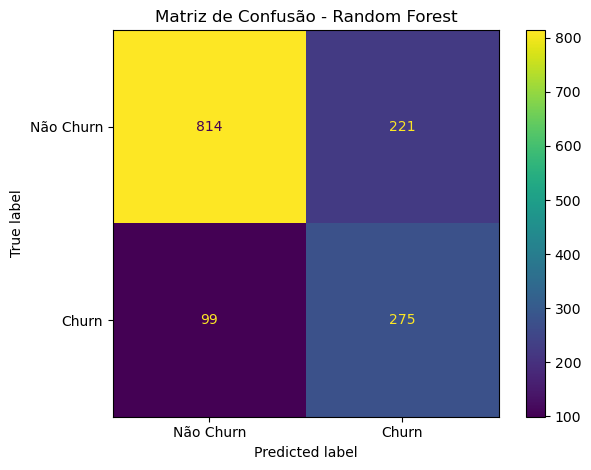

In [13]:
# ============================================================
# ETAPA 10.1 - MATRIZ DE CONFUSÃO
# ============================================================
# Construção da matriz de confusão do Random Forest.
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("Matriz de Confusão - Random Forest")
print("-" * 45)

print(
    f"Verdadeiros Negativos (TN): "
    f"{tn_rf:,}".replace(",", ".")
)

print(
    f"Falsos Positivos (FP): "
    f"{fp_rf:,}".replace(",", ".")
)

print(
    f"Falsos Negativos (FN): "
    f"{fn_rf:,}".replace(",", ".")
)

print(
    f"Verdadeiros Positivos (TP): "
    f"{tp_rf:,}".replace(",", ".")
)


ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "Não Churn",
        "Churn"
    ]
).plot(
    values_format="d"
)

plt.title(
    "Matriz de Confusão - Random Forest"
)

plt.tight_layout()

plt.show()

In [14]:
# ============================================================
# ETAPA 10.2 - INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO
# ============================================================

total_teste = len(y_test)


matriz_rf_df = pd.DataFrame({
    "Resultado": [
        "Verdadeiro Negativo (TN)",
        "Falso Positivo (FP)",
        "Falso Negativo (FN)",
        "Verdadeiro Positivo (TP)"
    ],

    "Quantidade": [
        tn_rf,
        fp_rf,
        fn_rf,
        tp_rf
    ],

    "Percentual da Base": [
        tn_rf / total_teste,
        fp_rf / total_teste,
        fn_rf / total_teste,
        tp_rf / total_teste
    ],

    "Interpretação": [
        (
            "Clientes que não realizaram churn e foram "
            "corretamente classificados pelo modelo como não churn."
        ),

        (
            "Clientes que não realizaram churn, mas foram classificados "
            "como churn. Podem gerar ações de retenção desnecessárias."
        ),

        (
            "Clientes que realizaram churn, mas não foram identificados "
            "pelo modelo. Representam oportunidades de retenção perdidas."
        ),

        (
            "Clientes que realizaram churn e foram corretamente "
            "identificados pelo modelo, permitindo priorizar possíveis "
            "ações de retenção."
        )
    ]
})


matriz_rf_df["Percentual da Base"] = (
    matriz_rf_df["Percentual da Base"]
    .map(lambda valor: f"{valor:.2%}")
)


display(
    matriz_rf_df.style
        .set_properties(
            subset=[
                "Resultado",
                "Quantidade",
                "Percentual da Base"
            ],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Interpretação"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "600px"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Resultado,Quantidade,Percentual da Base,Interpretação
0,Verdadeiro Negativo (TN),814,57.77%,Clientes que não realizaram churn e foram corretamente classificados pelo modelo como não churn.
1,Falso Positivo (FP),221,15.68%,"Clientes que não realizaram churn, mas foram classificados como churn. Podem gerar ações de retenção desnecessárias."
2,Falso Negativo (FN),99,7.03%,"Clientes que realizaram churn, mas não foram identificados pelo modelo. Representam oportunidades de retenção perdidas."
3,Verdadeiro Positivo (TP),275,19.52%,"Clientes que realizaram churn e foram corretamente identificados pelo modelo, permitindo priorizar possíveis ações de retenção."


#### Conclusão da ETAPA 10

A matriz de confusão permitiu compreender com maior profundidade o comportamento do Random Forest na identificação de clientes com risco de churn.

Entre as 1.409 observações do conjunto de teste, o modelo classificou corretamente 814 clientes que permaneceram e identificou corretamente 275 clientes que efetivamente realizaram churn.

Foram registrados 99 Falsos Negativos, correspondentes a clientes que realizaram churn, mas não foram identificados pelo modelo. Esse resultado está diretamente relacionado ao Recall de 73,53%, demonstrando que o Random Forest conseguiu detectar uma parcela significativa da classe positiva.

Por outro lado, foram observados 221 Falsos Positivos, representando clientes classificados como potenciais churns que, na realidade, permaneceram. Esse comportamento ajuda a explicar a Precision de 55,44% e evidencia o principal trade-off do modelo: maior capacidade de identificar clientes em risco em troca de um número maior de alertas incorretos.

Sob a perspectiva de negócio, esse comportamento pode ser relevante em cenários nos quais deixar de identificar um cliente que efetivamente realizará churn possui impacto maior do que realizar uma ação de retenção desnecessária. Entretanto, o custo associado aos Falsos Positivos deverá ser considerado na comparação final dos modelos.

Dessa forma, a matriz de confusão confirma que o Random Forest prioriza a identificação da classe positiva, comportamento coerente com o balanceamento das classes utilizado durante o treinamento.

---

### ETAPA 11 - Curva ROC

A Curva ROC (Receiver Operating Characteristic) permite avaliar a capacidade discriminativa do Random Forest considerando diferentes limiares de decisão.

A curva relaciona a Taxa de Verdadeiros Positivos (True Positive Rate) à Taxa de Falsos Positivos (False Positive Rate), permitindo observar como o comportamento do classificador se modifica à medida que o limiar de decisão é alterado.

A métrica ROC-AUC resume essa capacidade em um único valor, sendo utilizada como medida complementar para avaliar a habilidade do modelo em distinguir clientes com e sem churn.

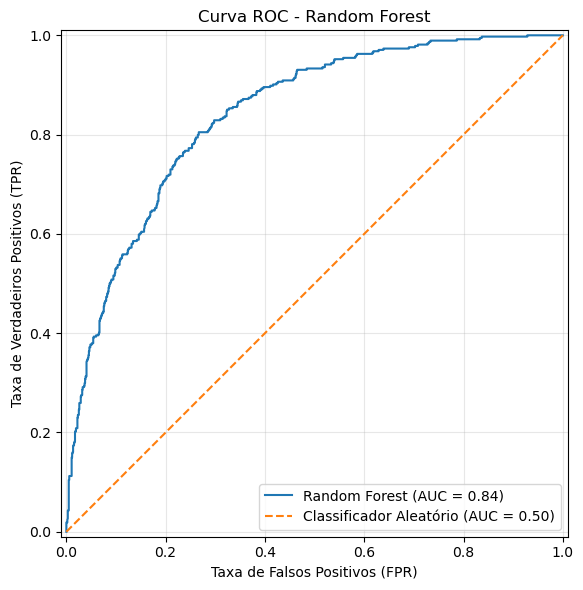

ROC-AUC do Random Forest: 0.8401 (84.01%)


In [18]:
# ============================================================
# ETAPA 11.1 - CURVA ROC
# ============================================================
# Construção da Curva ROC utilizando as probabilidades
# previstas pelo Random Forest.
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_rf,
    name="Random Forest",
    
    ax=ax
)


# Linha de referência para um classificador aleatório
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador Aleatório (AUC = 0.50)"
)


ax.set_title(
    "Curva ROC - Random Forest"
)

ax.set_xlabel(
    "Taxa de Falsos Positivos (FPR)"
)

ax.set_ylabel(
    "Taxa de Verdadeiros Positivos (TPR)"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


print(
    f"ROC-AUC do Random Forest: "
    f"{roc_auc_rf:.4f} ({roc_auc_rf:.2%})"
)

In [19]:
# ============================================================
# ETAPA 11.2 - INTERPRETAÇÃO DA CURVA ROC
# ============================================================

def classificar_roc_auc_rf(valor):
    """
    Classifica qualitativamente o desempenho da ROC-AUC.
    """

    if valor >= 0.90:
        return "Excelente"

    elif valor >= 0.80:
        return "Muito boa"

    elif valor >= 0.70:
        return "Boa"

    elif valor >= 0.60:
        return "Moderada"

    else:
        return "Baixa"


def interpretar_roc_auc_rf(valor):
    """
    Gera uma interpretação textual da ROC-AUC.
    """

    return (
        f"O Random Forest apresentou ROC-AUC de {valor:.2%}, "
        "demonstrando boa capacidade de distinguir clientes com "
        "e sem churn ao considerar diferentes limiares de decisão. "
        "O resultado está significativamente acima da referência "
        "de 50% associada a um classificador sem capacidade "
        "discriminativa."
    )


roc_rf_df = pd.DataFrame({
    "Métrica": [
        "ROC-AUC"
    ],

    "Valor": [
        round(
            roc_auc_rf,
            4
        )
    ],

    "Avaliação": [
        classificar_roc_auc_rf(
            roc_auc_rf
        )
    ],

    "Interpretação": [
        interpretar_roc_auc_rf(
            roc_auc_rf
        )
    ]
})


display(
    roc_rf_df.style
        .set_properties(
            subset=[
                "Métrica",
                "Valor",
                "Avaliação"
            ],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Interpretação"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "650px"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Métrica,Valor,Avaliação,Interpretação
0,ROC-AUC,0.840100,Muito boa,"O Random Forest apresentou ROC-AUC de 84.01%, demonstrando boa capacidade de distinguir clientes com e sem churn ao considerar diferentes limiares de decisão. O resultado está significativamente acima da referência de 50% associada a um classificador sem capacidade discriminativa."


#### Conclusão da ETAPA 11

A Curva ROC demonstrou que o Random Forest apresenta boa capacidade discriminativa ao longo de diferentes limiares de classificação.

A ROC-AUC obtida foi de 84,01%, valor consideravelmente superior à referência de 50% associada a um classificador sem capacidade discriminativa. Esse resultado indica que o modelo consegue estabelecer uma separação consistente entre clientes com e sem churn.

O resultado também demonstra que o desempenho do Random Forest não depende exclusivamente do limiar padrão de classificação, mantendo capacidade de discriminação quando diferentes pontos de decisão são considerados.

Embora a ROC-AUC forneça uma visão importante do desempenho global do classificador, o desbalanceamento existente entre as classes torna necessária uma análise complementar da relação entre Precision e Recall. Por esse motivo, a próxima etapa avaliará a Curva Precision-Recall e a Average Precision.

---

### ETAPA 12 - Curva Precision-Recall

A Curva Precision-Recall permite analisar o equilíbrio entre Precision e Recall ao longo de diferentes limiares de classificação.

Essa análise é especialmente relevante em problemas com classes desbalanceadas, como a previsão de churn, pois concentra a avaliação no desempenho do modelo em relação à classe positiva.

Neste projeto, a Average Precision é utilizada como principal referência técnica para comparação entre os modelos, complementando as demais métricas de classificação.

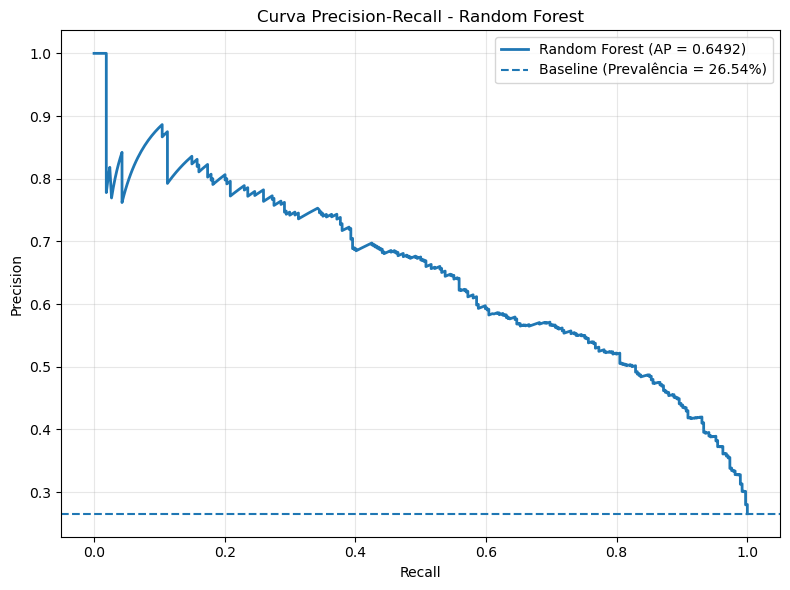

Average Precision do Random Forest: 0.6492 (64.92%)
Prevalência de churn no conjunto de teste: 0.2654 (26.54%)


In [20]:
# ============================================================
# ETAPA 12.1 - CURVA PRECISION-RECALL
# ============================================================
# Construção da Curva Precision-Recall utilizando as
# probabilidades previstas pelo Random Forest.
# ============================================================

precision_curve_rf, recall_curve_rf, thresholds_rf = (
    precision_recall_curve(
        y_test,
        y_proba_rf
    )
)

# Prevalência da classe positiva no conjunto de teste
prevalencia_churn_teste = y_test.mean()


fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    recall_curve_rf,
    precision_curve_rf,
    linewidth=2,
    label=(
        f"Random Forest "
        f"(AP = {average_precision_rf:.4f})"
    )
)

# Linha de referência baseada na prevalência da classe positiva
ax.axhline(
    y=prevalencia_churn_teste,
    linestyle="--",
    label=(
        f"Baseline "
        f"(Prevalência = {prevalencia_churn_teste:.2%})"
    )
)

ax.set_title(
    "Curva Precision-Recall - Random Forest"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.legend(
    loc="best"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


print(
    f"Average Precision do Random Forest: "
    f"{average_precision_rf:.4f} "
    f"({average_precision_rf:.2%})"
)

print(
    f"Prevalência de churn no conjunto de teste: "
    f"{prevalencia_churn_teste:.4f} "
    f"({prevalencia_churn_teste:.2%})"
)

In [21]:
# ============================================================
# ETAPA 12.2 - INTERPRETAÇÃO DA AVERAGE PRECISION
# ============================================================


def classificar_average_precision_rf(valor):
    """
    Classifica qualitativamente a Average Precision.
    """

    if valor >= 0.90:
        return "Excelente"

    elif valor >= 0.80:
        return "Muito boa"

    elif valor >= 0.70:
        return "Boa"

    elif valor >= 0.60:
        return "Moderada"

    else:
        return "Baixa"


def interpretar_average_precision_rf(
    valor,
    prevalencia
):
    """
    Gera uma interpretação textual da Average Precision
    considerando também a prevalência da classe positiva.
    """

    ganho_absoluto = valor - prevalencia

    return (
        f"O Random Forest apresentou Average Precision de "
        f"{valor:.2%}, enquanto a prevalência de churn no conjunto "
        f"de teste é de {prevalencia:.2%}. "
        f"Isso representa um ganho absoluto de aproximadamente "
        f"{ganho_absoluto:.2%} em relação à referência baseada na "
        f"prevalência da classe positiva. O resultado demonstra que "
        f"o modelo possui capacidade relevante de priorizar clientes "
        f"com maior risco de churn."
    )


pr_rf_df = pd.DataFrame({
    "Métrica": [
        "Average Precision"
    ],

    "Valor": [
        round(
            average_precision_rf,
            4
        )
    ],

    "Baseline": [
        round(
            prevalencia_churn_teste,
            4
        )
    ],

    "Avaliação": [
        classificar_average_precision_rf(
            average_precision_rf
        )
    ],

    "Interpretação": [
        interpretar_average_precision_rf(
            average_precision_rf,
            prevalencia_churn_teste
        )
    ]
})


display(
    pr_rf_df.style
        .set_properties(
            subset=[
                "Métrica",
                "Valor",
                "Baseline",
                "Avaliação"
            ],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Interpretação"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "700px"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Métrica,Valor,Baseline,Avaliação,Interpretação
0,Average Precision,0.649200,0.265400,Moderada,"O Random Forest apresentou Average Precision de 64.92%, enquanto a prevalência de churn no conjunto de teste é de 26.54%. Isso representa um ganho absoluto de aproximadamente 38.38% em relação à referência baseada na prevalência da classe positiva. O resultado demonstra que o modelo possui capacidade relevante de priorizar clientes com maior risco de churn."


#### Conclusão da ETAPA 12

A Curva Precision-Recall evidenciou a capacidade do Random Forest de identificar e priorizar clientes pertencentes à classe positiva em um cenário de classes desbalanceadas.

O modelo apresentou Average Precision de 64,92%, resultado significativamente superior à prevalência de churn de aproximadamente 26,54% observada no conjunto de teste. Essa diferença demonstra que as probabilidades produzidas pelo modelo apresentam capacidade preditiva relevante para distinguir e ordenar clientes de acordo com seu risco de churn.

A análise também complementa o Recall de 73,53% observado anteriormente, mostrando que o Random Forest consegue identificar uma parcela expressiva dos clientes que efetivamente realizam churn, embora exista um trade-off com a Precision.

Como a Average Precision foi definida como principal referência técnica do projeto, o resultado de 64,92% será posteriormente utilizado na comparação com os demais modelos.

Apesar do desempenho observado no conjunto de teste, ainda é necessário avaliar a estabilidade do Random Forest em diferentes subconjuntos dos dados. Por esse motivo, a próxima etapa utilizará validação cruzada estratificada para analisar a robustez e a capacidade de generalização do modelo.

---

### ETAPA 13 - Validação Cruzada Estratificada

Até este momento, o desempenho do Random Forest foi avaliado utilizando uma única divisão entre os conjuntos de treinamento e teste.

Embora essa abordagem seja importante para manter um conjunto independente destinado à avaliação final, uma única divisão pode não representar completamente a variabilidade existente nos dados.

Nesta etapa será aplicada validação cruzada estratificada sobre o conjunto de treinamento. A técnica divide os dados em múltiplos subconjuntos (folds), preservando aproximadamente a proporção das classes em cada divisão.

O conjunto de teste permanecerá separado e não participará da validação cruzada, evitando que informações utilizadas na avaliação final influenciem o processo de análise do modelo.

Serão avaliadas as mesmas métricas utilizadas anteriormente, com destaque para Average Precision, definida como principal referência técnica do projeto.

In [22]:
# ============================================================
# ETAPA 13.1 - CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA
# ============================================================

cv_rf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Validação cruzada configurada com sucesso.")

print(
    f"Número de folds: "
    f"{cv_rf.get_n_splits()}"
)

print(
    "Estratégia: StratifiedKFold"
)

print(
    "Shuffle: True"
)

print(
    f"Random State: "
    f"{RANDOM_STATE}"
)

Validação cruzada configurada com sucesso.
Número de folds: 5
Estratégia: StratifiedKFold
Shuffle: True
Random State: 42


In [23]:
# ============================================================
# ETAPA 13.2 - EXECUÇÃO DA VALIDAÇÃO CRUZADA
# ============================================================

scoring_rf = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}


cv_results_rf = cross_validate(
    estimator=random_forest_pipeline,
    X=X_train,
    y=y_train,
    cv=cv_rf,
    scoring=scoring_rf,
    return_train_score=False,
    n_jobs=-1
)


print("Validação cruzada concluída com sucesso.")

print(
    f"Quantidade de folds avaliados: "
    f"{len(cv_results_rf['test_accuracy'])}"
)

Validação cruzada concluída com sucesso.
Quantidade de folds avaliados: 5


In [24]:
# ============================================================
# ETAPA 13.3 - RESULTADOS POR FOLD
# ============================================================

cv_folds_rf_df = pd.DataFrame({
    "Fold": range(
        1,
        6
    ),

    "Accuracy": cv_results_rf[
        "test_accuracy"
    ],

    "Precision": cv_results_rf[
        "test_precision"
    ],

    "Recall": cv_results_rf[
        "test_recall"
    ],

    "F1-Score": cv_results_rf[
        "test_f1"
    ],

    "ROC-AUC": cv_results_rf[
        "test_roc_auc"
    ],

    "Average Precision": cv_results_rf[
        "test_average_precision"
    ]
})

# Arredondamento para visualização
colunas_metricas_rf = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Average Precision"
]

cv_folds_rf_df[
    colunas_metricas_rf
] = (
    cv_folds_rf_df[
        colunas_metricas_rf
    ]
    .round(4)
)

display(
    cv_folds_rf_df.style
        .set_properties(
            **{
                "text-align": "center"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
0,1,0.779100,0.563500,0.742500,0.640700,0.839700,0.625700
1,2,0.759500,0.537800,0.665600,0.594900,0.832900,0.640900
2,3,0.768400,0.547500,0.732400,0.626600,0.844000,0.681800
3,4,0.781700,0.566800,0.752500,0.646600,0.849500,0.660700
4,5,0.785100,0.576400,0.719100,0.639900,0.858500,0.665900


In [25]:
# ============================================================
# ETAPA 13.4 - MÉDIA E DESVIO-PADRÃO
# ============================================================

metricas_cv_rf = {
    "Accuracy": cv_results_rf[
        "test_accuracy"
    ],

    "Precision": cv_results_rf[
        "test_precision"
    ],

    "Recall": cv_results_rf[
        "test_recall"
    ],

    "F1-Score": cv_results_rf[
        "test_f1"
    ],

    "ROC-AUC": cv_results_rf[
        "test_roc_auc"
    ],

    "Average Precision": cv_results_rf[
        "test_average_precision"
    ]
}


resumo_cv_rf = []


for metrica, valores in metricas_cv_rf.items():

    media = np.mean(
        valores
    )

    desvio = np.std(
        valores
    )

    resumo_cv_rf.append({
        "Métrica": metrica,
        "Média": media,
        "Desvio-Padrão": desvio,
        "Resultado": (
            f"{media:.2%} ± "
            f"{desvio:.2%}"
        )
    })


cv_resumo_rf_df = pd.DataFrame(
    resumo_cv_rf
)


cv_resumo_rf_df["Média"] = (
    cv_resumo_rf_df["Média"]
    .round(4)
)

cv_resumo_rf_df["Desvio-Padrão"] = (
    cv_resumo_rf_df["Desvio-Padrão"]
    .round(4)
)


display(
    cv_resumo_rf_df.style
        .set_properties(
            subset=[
                "Métrica",
                "Média",
                "Desvio-Padrão",
                "Resultado"
            ],
            **{
                "text-align": "center"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Métrica,Média,Desvio-Padrão,Resultado
0,Accuracy,0.774800,0.009400,77.48% ± 0.94%
1,Precision,0.558400,0.013900,55.84% ± 1.39%
2,Recall,0.722400,0.030500,72.24% ± 3.05%
3,F1-Score,0.629700,0.018600,62.97% ± 1.86%
4,ROC-AUC,0.844900,0.008700,84.49% ± 0.87%
5,Average Precision,0.655000,0.019600,65.50% ± 1.96%


In [26]:
# ============================================================
# ETAPA 13.5 - VALIDAÇÃO CRUZADA VS CONJUNTO DE TESTE
# ============================================================

comparacao_cv_teste_rf = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision"
    ],

    "Média CV": [
        np.mean(
            cv_results_rf["test_accuracy"]
        ),

        np.mean(
            cv_results_rf["test_precision"]
        ),

        np.mean(
            cv_results_rf["test_recall"]
        ),

        np.mean(
            cv_results_rf["test_f1"]
        ),

        np.mean(
            cv_results_rf["test_roc_auc"]
        ),

        np.mean(
            cv_results_rf[
                "test_average_precision"
            ]
        )
    ],

    "Teste": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        average_precision_rf
    ]
})


comparacao_cv_teste_rf[
    "Diferença Absoluta"
] = (
    comparacao_cv_teste_rf[
        "Teste"
    ]
    -
    comparacao_cv_teste_rf[
        "Média CV"
    ]
).abs()


comparacao_cv_teste_rf[
    [
        "Média CV",
        "Teste",
        "Diferença Absoluta"
    ]
] = (
    comparacao_cv_teste_rf[
        [
            "Média CV",
            "Teste",
            "Diferença Absoluta"
        ]
    ]
    .round(4)
)


display(
    comparacao_cv_teste_rf.style
        .set_properties(
            **{
                "text-align": "center"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Métrica,Média CV,Teste,Diferença Absoluta
0,Accuracy,0.774800,0.772900,0.001900
1,Precision,0.558400,0.554400,0.004000
2,Recall,0.722400,0.735300,0.012900
3,F1-Score,0.629700,0.632200,0.002500
4,ROC-AUC,0.844900,0.840100,0.004800
5,Average Precision,0.655000,0.649200,0.005800


#### Conclusão da ETAPA 13

A validação cruzada estratificada com cinco folds demonstrou que o Random Forest apresenta desempenho consistente entre diferentes subconjuntos dos dados de treinamento.

A principal métrica do projeto, Average Precision, apresentou média de 65,50% e desvio-padrão de 1,96%. No conjunto de teste independente, o resultado foi de 64,92%, representando uma diferença absoluta de apenas 0,58 ponto percentual em relação à média da validação cruzada.

A ROC-AUC também apresentou elevada estabilidade, com média de 84,49% e desvio-padrão de apenas 0,87%, enquanto o conjunto de teste apresentou 84,01%.

O Recall apresentou a maior variabilidade entre as métricas avaliadas, com média de 72,24% e desvio-padrão de 3,05%. Ainda assim, o resultado obtido no conjunto de teste, de 73,53%, permaneceu próximo ao comportamento médio observado durante a validação.

As demais métricas também apresentaram pequenas diferenças entre a média da validação cruzada e o conjunto de teste: 0,19 ponto percentual para Accuracy, 0,40 para Precision e 0,25 para F1-Score.

De forma geral, a proximidade entre os resultados da validação cruzada e do conjunto de teste fornece evidências de estabilidade e capacidade de generalização do Random Forest. Não foram observadas, nesta análise, diferenças expressivas que indiquem forte dependência de uma divisão específica dos dados.

O modelo seguirá para a análise de importância das variáveis, permitindo compreender quais características apresentam maior contribuição para as decisões realizadas pelo Random Forest.

---

### ETAPA 14 - Importância das Variáveis

Além do desempenho preditivo, é importante compreender quais características possuem maior influência nas decisões realizadas pelo Random Forest.

O algoritmo permite estimar a importância das variáveis com base na contribuição de cada feature para as divisões realizadas pelas árvores do ensemble.

Como as variáveis categóricas foram transformadas por One-Hot Encoding, a análise será realizada inicialmente sobre as features resultantes do pré-processamento.

A importância calculada pelo Random Forest deve ser interpretada como uma medida de contribuição preditiva do modelo, e não como evidência de causalidade entre uma característica e a ocorrência de churn.

In [29]:
# ============================================================
# ETAPA 14.1 - EXTRAÇÃO DA IMPORTÂNCIA DAS FEATURES
# ============================================================

# Recuperação do pré-processador treinado
preprocessor_treinado = (
    random_forest_pipeline
    .named_steps["preprocessor"]
)

# Recuperação do classificador treinado
modelo_rf_treinado = (
    random_forest_pipeline
    .named_steps["classifier"]
)

# Nomes das features após o pré-processamento
feature_names_rf = (
    preprocessor_treinado
    .get_feature_names_out()
)

# Importâncias calculadas pelo Random Forest
feature_importances_rf = (
    modelo_rf_treinado
    .feature_importances_
)

# Validação
if len(feature_names_rf) != len(feature_importances_rf):
    raise ValueError(
        "A quantidade de nomes das features é diferente "
        "da quantidade de importâncias calculadas."
    )

# Construção da tabela
feature_importance_rf_df = pd.DataFrame({
    "Feature": feature_names_rf,
    "Importância": feature_importances_rf
})

# Remoção dos prefixos gerados pelo ColumnTransformer
feature_importance_rf_df["Feature"] = (
    feature_importance_rf_df["Feature"]
    .str.replace(
        "num__",
        "",
        regex=False
    )
    .str.replace(
        "cat__",
        "",
        regex=False
    )
)

# Ordenação
feature_importance_rf_df = (
    feature_importance_rf_df
    .sort_values(
        by="Importância",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

# Participação percentual
feature_importance_rf_df[
    "Importância (%)"
] = (
    feature_importance_rf_df[
        "Importância"
    ]
    * 100
)

# Exibição das 15 features mais importantes
top_15_features_rf = (
    feature_importance_rf_df
    .head(15)
    .copy()
)

top_15_features_rf["Importância"] = (
    top_15_features_rf["Importância"]
    .round(4)
)

top_15_features_rf["Importância (%)"] = (
    top_15_features_rf["Importância (%)"]
    .round(2)
)

display(
    top_15_features_rf.style
        .set_properties(
            subset=["Feature"],
            **{
                "text-align": "left"
            }
        )
        .set_properties(
            subset=[
                "Importância",
                "Importância (%)"
            ],
            **{
                "text-align": "center"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Feature,Importância,Importância (%)
0,tenure,0.128800,12.880000
1,Contract_Month-to-month,0.120500,12.050000
2,TotalCharges,0.100700,10.070000
3,MonthlyCharges,0.074100,7.410000
4,OnlineSecurity_No,0.060500,6.050000
5,Contract_Two year,0.059500,5.950000
6,InternetService_Fiber optic,0.050500,5.050000
7,TechSupport_No,0.048500,4.850000
8,PaymentMethod_Electronic check,0.035900,3.590000
9,Contract_One year,0.019200,1.920000


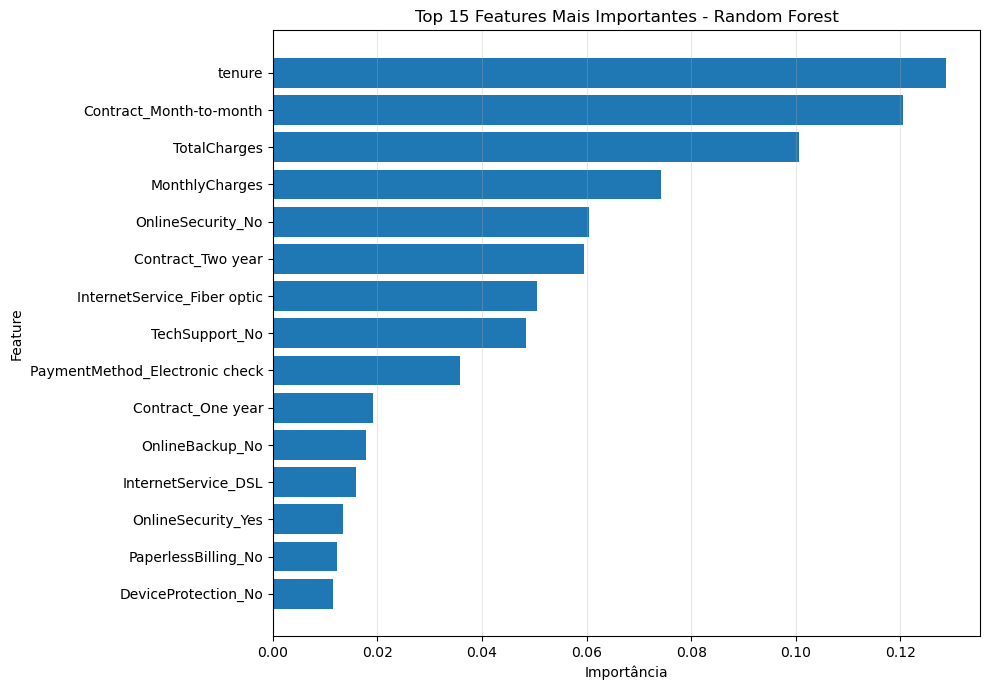

In [30]:
# ============================================================
# ETAPA 14.2 - VISUALIZAÇÃO DAS FEATURES MAIS IMPORTANTES
# ============================================================

top_features_plot_rf = (
    feature_importance_rf_df
    .head(15)
    .sort_values(
        by="Importância",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(10, 7)
)


ax.barh(
    top_features_plot_rf["Feature"],
    top_features_plot_rf["Importância"]
)


ax.set_title(
    "Top 15 Features Mais Importantes - Random Forest"
)

ax.set_xlabel(
    "Importância"
)

ax.set_ylabel(
    "Feature"
)

ax.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

#### Conclusão da ETAPA 14

A análise de importância das variáveis permitiu identificar quais características tiveram maior contribuição para as decisões realizadas pelo Random Forest.

A variável `tenure`, relacionada ao tempo de permanência do cliente na empresa, apresentou a maior importância individual, com 12,88%. Em seguida, destacou-se `Contract_Month-to-month`, com 12,05%, demonstrando a relevância do tipo de contrato para as decisões realizadas pelo modelo.

As variáveis financeiras também apresentaram participação expressiva. `TotalCharges` alcançou 10,07% de importância e `MonthlyCharges` 7,41%, indicando que características relacionadas ao histórico e ao valor das cobranças possuem contribuição relevante para a classificação.

Entre as características relacionadas aos serviços contratados, destacaram-se `OnlineSecurity_No` (6,05%), `InternetService_Fiber optic` (5,05%) e `TechSupport_No` (4,85%). A modalidade de pagamento `PaymentMethod_Electronic check` também apareceu entre as principais features, com 3,59%.

As diferentes categorias da variável `Contract` aparecem repetidamente entre as features mais relevantes, reforçando a importância das características contratuais para as decisões do Random Forest.

É importante destacar que a importância calculada pelo Random Forest representa contribuição preditiva dentro do modelo e não estabelece relação causal entre essas características e a ocorrência de churn.

De forma geral, os resultados indicam que tempo de relacionamento, modalidade contratual, características financeiras e determinados serviços possuem papel relevante nas previsões realizadas pelo Random Forest. Esses fatores também podem servir como pontos de atenção para análises posteriores relacionadas às estratégias de retenção.

---

### ETAPA 15 - Conclusão Geral

O desenvolvimento do Random Forest permitiu avaliar uma abordagem baseada em ensemble de árvores para o problema de previsão de churn, mantendo o mesmo conjunto de dados e protocolo de avaliação utilizado anteriormente no modelo baseline.

O modelo foi treinado utilizando 300 árvores, mecanismos de regularização e balanceamento das classes por meio de `class_weight="balanced"`. Essa configuração apresentou comportamento particularmente voltado à identificação da classe positiva.

No conjunto de teste, o Random Forest apresentou os seguintes resultados:

| Métrica | Resultado |
|---|---:|
| Accuracy | 77,29% |
| Precision | 55,44% |
| Recall | 73,53% |
| F1-Score | 63,22% |
| ROC-AUC | 84,01% |
| Average Precision | 64,92% |

O Recall de 73,53% demonstra que o modelo conseguiu identificar uma parcela significativa dos clientes que efetivamente realizaram churn. A matriz de confusão confirmou esse comportamento, com 275 Verdadeiros Positivos e 99 Falsos Negativos.

Em contrapartida, foram registrados 221 Falsos Positivos, contribuindo para uma Precision de 55,44%. O resultado evidencia um trade-off entre ampliar a identificação de clientes em risco e aumentar a quantidade de clientes incorretamente sinalizados para possíveis ações de retenção.

A Average Precision, definida como principal referência técnica do projeto, alcançou 64,92%, resultado consideravelmente superior à prevalência de churn de 26,54% no conjunto de teste. A ROC-AUC de 84,01% também demonstrou boa capacidade discriminativa ao longo de diferentes limiares de decisão.

A validação cruzada estratificada com cinco folds reforçou a estabilidade do modelo. A Average Precision média foi de 65,50% ± 1,96%, enquanto a ROC-AUC média atingiu 84,49% ± 0,87%. A proximidade desses valores com os resultados do conjunto de teste fornece evidências favoráveis sobre a capacidade de generalização do Random Forest.

A análise de importância das features mostrou maior contribuição de características relacionadas ao tempo de relacionamento, modalidade contratual, cobranças e serviços. `tenure`, `Contract_Month-to-month`, `TotalCharges` e `MonthlyCharges` estiveram entre as características de maior importância para as decisões do modelo.

### Comparação preliminar com o baseline

Em relação à Regressão Logística utilizada como baseline, o Random Forest apresentou comportamentos distintos:

| Métrica | Regressão Logística | Random Forest | Diferença |
|---|---:|---:|---:|
| Accuracy | 80,55% | 77,29% | -3,26 p.p. |
| Precision | 65,72% | 55,44% | -10,28 p.p. |
| Recall | 55,88% | 73,53% | +17,65 p.p. |
| F1-Score | 60,40% | 63,22% | +2,82 p.p. |
| ROC-AUC | 84,19% | 84,01% | -0,18 p.p. |
| Average Precision | 63,34% | 64,92% | +1,58 p.p. |

O principal ganho do Random Forest ocorreu no Recall, com aumento de 17,65 pontos percentuais, além de melhorias no F1-Score e na Average Precision. Por outro lado, houve redução na Accuracy e, principalmente, na Precision.

A ROC-AUC permaneceu praticamente estável entre os dois modelos.

Esses resultados mostram que a escolha do melhor modelo não deve ser realizada considerando apenas uma métrica isoladamente. O impacto dos Falsos Positivos e Falsos Negativos, a estabilidade dos modelos e as métricas técnicas e de negócio deverão ser considerados conjuntamente na decisão final.

Neste momento, portanto, o Random Forest não será declarado como modelo vencedor. A próxima etapa do projeto será o desenvolvimento do `MLPClassifier`, permitindo posteriormente realizar uma comparação consolidada entre Regressão Logística, Random Forest e Rede Neural.

---